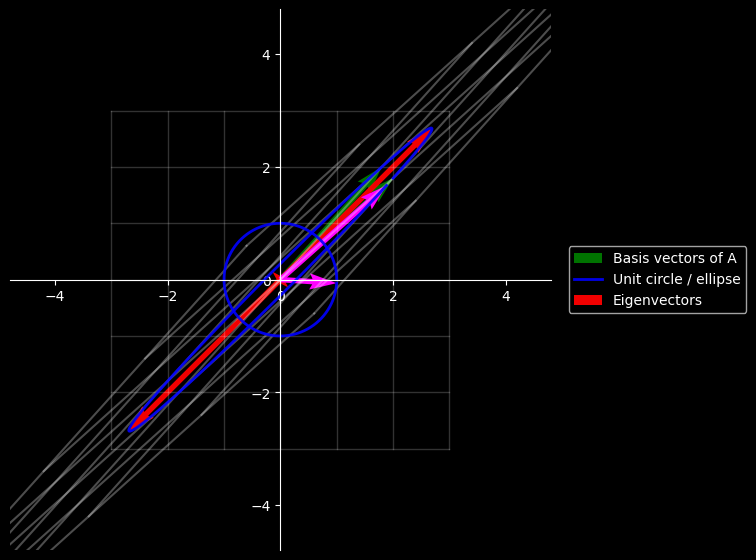

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.style.use("dark_background")

# ============================================================
# Helpers
# ============================================================
def center_spines(ax):
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

def draw_linear_grid(ax, A, grid_lim=3, step=1, color="gray", alpha=0.25, lw=1.0):
    """
    Draw the image under A of the integer grid lines in the (u,v)-coordinate plane.
    That is, we draw lines of the form:
        u = const, v varying   and   v = const, u varying
    mapped into x-y by: x = A @ [u, v].
    """
    u_vals = np.arange(-grid_lim, grid_lim + step, step)
    v_vals = np.arange(-grid_lim, grid_lim + step, step)

    # For each fixed u (a "vertical" line in uv-plane): v sweeps
    for u0 in u_vals:
        uv = np.stack([np.full_like(v_vals, u0, dtype=float), v_vals.astype(float)], axis=0)  # shape (2, m)
        xy = A @ uv  # shape (2, m)
        ax.plot(xy[0], xy[1], color=color, alpha=alpha, lw=lw)

    # For each fixed v (a "horizontal" line in uv-plane): u sweeps
    for v0 in v_vals:
        uv = np.stack([u_vals.astype(float), np.full_like(u_vals, v0, dtype=float)], axis=0)  # shape (2, m)
        xy = A @ uv
        ax.plot(xy[0], xy[1], color=color, alpha=alpha, lw=lw)

# ============================================================
# Data: circle points + transform
# ============================================================
n_pts = 100
angles = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)
unit_vectors = np.column_stack([np.cos(angles), np.sin(angles)])  # (n_pts, 2)

A = np.array([[2, 1.8],
              [1.8, 2]], dtype=float)

transformed_vectors = unit_vectors @ A.T

# Eigen-decomposition
eigenvalues, eigenvectors = np.linalg.eig(A)          # eigenvectors are columns
eigenvectors_scaled = eigenvectors * eigenvalues      # scale each column by its eigenvalue

# ============================================================
# Plot setup
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
plt.tight_layout()

center_spines(ax)
ax.set_aspect("equal", "box")

# Choose limits based on transform magnitude
r = np.max(np.linalg.norm(transformed_vectors, axis=1))
pad = 1.0
lim = max(3.0, r + pad)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

# ============================================================
# Coordinate system / grid
# - Show the standard grid (optional, faint)
# - Show the A-transformed grid (this is the "coordinate system of A")
# - Show Ae1 and Ae2 explicitly
# ============================================================
# Optional: standard grid in xy plane
grid_lim = 3
for t in range(-grid_lim, grid_lim + 1):
    ax.plot([-grid_lim, grid_lim], [t, t], color="white", alpha=0.2, lw=1)
    ax.plot([t, t], [-grid_lim, grid_lim], color="white", alpha=0.2, lw=1)

# Transformed grid under A
draw_linear_grid(ax, A, grid_lim=3, step=1, color="white", alpha=0.3, lw=1.5)

# Standard basis and its images under A
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])
Ae1 = A @ e1
Ae2 = A @ e2

# Transformed basis
ax.quiver(0, 0, Ae1[0], Ae1[1], angles="xy", scale_units="xy", scale=1,
          color="green", width=0.01, alpha=0.9, label="Basis vectors of A")
ax.quiver(0, 0, Ae2[0], Ae2[1], angles="xy", scale_units="xy", scale=1,
          color="green", width=0.01, alpha=0.9)

# ============================================================
# Circle and ellipse outlines (static)
# ============================================================
ax.plot(unit_vectors[:, 0], unit_vectors[:, 1],
        color="blue", linestyle="-", alpha=0.9, linewidth=2, label="Unit circle / ellipse")
ax.plot(transformed_vectors[:, 0], transformed_vectors[:, 1],
        color="blue", linestyle="-", alpha=0.9, linewidth=2)

# ============================================================
# Eigenvectors (scaled) as arrows
# ============================================================
# Plot eigenvectors in BOTH positive and negative directions
for i in range(2):
    vx = eigenvectors_scaled[0, i]
    vy = eigenvectors_scaled[1, i]
    
    # Positive direction
    ax.quiver(0, 0, vx, vy,
              angles="xy", scale_units="xy", scale=1,
              color="red", width=0.01, alpha=0.95,
              label="Eigenvectors" if i == 0 else None)
    
    # Negative direction
    ax.quiver(0, 0, -vx, -vy,
              angles="xy", scale_units="xy", scale=1,
              color="red", width=0.01, alpha=0.95)

# ============================================================
# Animated arrows (original + transformed)
# ============================================================
orig_q = ax.quiver(0, 0, 0, 0, angles="xy", scale_units="xy", scale=1,
                   color="magenta", width=0.010)
trans_q = ax.quiver(0, 0, 0, 0, angles="xy", scale_units="xy", scale=1,
                    color="magenta", width=0.010)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

def init():
    orig_q.set_UVC([0], [0])
    trans_q.set_UVC([0], [0])
    return orig_q, trans_q

def animate(i):
    x_orig, y_orig = unit_vectors[i]
    x_trans, y_trans = transformed_vectors[i]
    orig_q.set_UVC([x_orig], [y_orig])
    trans_q.set_UVC([x_trans], [y_trans])
    return orig_q, trans_q

ani = FuncAnimation(fig, animate, frames=n_pts, init_func=init, blit=True, interval=50)

# Save animation
ani.save("Eigenvectors_UnitCircle.gif", fps=20)

plt.show()